# Evaluate

Here we will evaluate the models using various test including:
Accuracy - Out of all the predictions, how many did the model get right 
Precision - Out of the predictions the model classified as true, how many actually are.
Recall - Out of all the predictions that are actually true, how many did the model get correct
AUC - Area under the curve, is the model's ability to distinguish between true and false. 0.5 (random) to 1(prefect)

In [1]:
import sys
from pathlib import Path

sys.path.append('../')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import classification_report, roc_auc_score,roc_curve,RocCurveDisplay,accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



trained_models = joblib.load(Path("../data/processed/05_trained_models.joblib"))
splits = joblib.load(Path("../data/processed/04_features_splits.joblib"))

In [2]:
trained_models['L3']['LogisticRegression']

LogisticRegression(random_state=42)

In [3]:
X_l3_train = splits['X_l3_train']
X_l3_test = splits['X_l3_test']
y_l3_train = splits['y_l3_train']
y_l3_test = splits['y_l3_test']

X_l4_train = splits['X_l4_train']
X_l4_test = splits['X_l4_test']
y_l4_train = splits['y_l4_train']
y_l4_test = splits['y_l4_test']

X_l7_train = splits['X_l7_train']
X_l7_test = splits['X_l7_test']
y_l7_train = splits['y_l7_train']
y_l7_test = splits['y_l7_test']

In [4]:
models = [
    'LogisticRegression',
    'DecisionTree',
    'RandomForest',
    'GradientBoosting']

level_splits = {
    'L3': (X_l3_train, X_l3_test, y_l3_train, y_l3_test),
    'L4': (X_l4_train, X_l4_test, y_l4_train, y_l4_test),
    'L7': (X_l7_train, X_l7_test, y_l7_train, y_l7_test)
}

levels = ['L3',
          'L4',
          'L7'   
]


In [6]:
results = []

for level,splits in level_splits.items():
    X_train,X_test,y_train,y_test = splits
    for model_name in models:
        y_pred = trained_models[level][model_name].predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)

        print(f"\n{level} — {model_name}")
        print(classification_report(y_test, y_pred))

        results.append({'level': level,
                        'model': model_name,
                        'accuracy': accuracy,
                        'precision': precision,
                        'recall': recall,
                        'roc_auc': auc
                        })

results_df = pd.DataFrame(results)          


L3 — LogisticRegression
              precision    recall  f1-score   support

           0       0.36      1.00      0.53         8
           1       0.00      0.00      0.00        14

    accuracy                           0.36        22
   macro avg       0.18      0.50      0.27        22
weighted avg       0.13      0.36      0.19        22


L3 — DecisionTree
              precision    recall  f1-score   support

           0       0.36      1.00      0.53         8
           1       0.00      0.00      0.00        14

    accuracy                           0.36        22
   macro avg       0.18      0.50      0.27        22
weighted avg       0.13      0.36      0.19        22


L3 — RandomForest
              precision    recall  f1-score   support

           0       0.36      1.00      0.53         8
           1       0.00      0.00      0.00        14

    accuracy                           0.36        22
   macro avg       0.18      0.50      0.27        22
weighted av

C:\Users\ashma\anaconda3\envs\grade-profile-ml\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ashma\anaconda3\envs\grade-profile-ml\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ashma\anaconda3\envs\grade-profile-ml\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} 

In [7]:
print(results_df)

   level               model  accuracy  precision  recall  roc_auc
0     L3  LogisticRegression  0.363636        0.0     0.0      0.5
1     L3        DecisionTree  0.363636        0.0     0.0      0.5
2     L3        RandomForest  0.363636        0.0     0.0      0.5
3     L3    GradientBoosting  0.363636        0.0     0.0      0.5
4     L4  LogisticRegression  0.486486        0.0     0.0      0.5
5     L4        DecisionTree  0.486486        0.0     0.0      0.5
6     L4        RandomForest  0.486486        0.0     0.0      0.5
7     L4    GradientBoosting  0.486486        0.0     0.0      0.5
8     L7  LogisticRegression  0.950000        0.0     0.0      0.5
9     L7        DecisionTree  0.950000        0.0     0.0      0.5
10    L7        RandomForest  0.950000        0.0     0.0      0.5
11    L7    GradientBoosting  0.950000        0.0     0.0      0.5


In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for level, splits in level_splits.items():
    X_train, X_test, y_train, y_test = splits
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])
    
    for model_name in models:
        model = trained_models[level][model_name]
        scores = cross_val_score(model, X_all, y_all, cv=cv, scoring='roc_auc')
        cv_results.append({
            'level': level,
            'model': model_name,
            'mean_auc': scores.mean().round(3),
            'std_auc': scores.std().round(3)
        })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

   level               model  mean_auc  std_auc
0     L3  LogisticRegression     0.477    0.091
1     L3        DecisionTree     0.500    0.088
2     L3        RandomForest     0.484    0.096
3     L3    GradientBoosting     0.502    0.086
4     L4  LogisticRegression     0.590    0.150
5     L4        DecisionTree     0.463    0.120
6     L4        RandomForest     0.466    0.114
7     L4    GradientBoosting     0.462    0.120
8     L7  LogisticRegression     0.710    0.183
9     L7        DecisionTree     0.710    0.183
10    L7        RandomForest     0.710    0.183
11    L7    GradientBoosting     0.710    0.183


## Adding level as a Feature

Due to the lack of useful predictions using the stratified approach, I will use the unstratified model as a baseline. 
However, this introduces a confound issue with level and EPAO as it incorrectly makes imbalanced predictions for learners on BCS due to the higher proportion of learners being in L7. 

I want to use this as an initial model test to showcase the predictions and then my further thinking to stratify justifiably on level.

I expect the combined model to show higher AUC due to Level's strong predictive power, but this should be interpreted as Level membership prediction rather than genuine distinction probability.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [12]:
df_combined = pd.read_parquet(Path("../data/processed/03_prep_clean.parquet"))
df_combined.head()

,current_prog,level,completion_date,grade,is_distinction,epao_AIM,epao_AP,epao_BCS,age_bracket_30-49,age_bracket_50+
0,L3 NHS Data Citizen Apprenticeship Standard,3,2023-03-06,Pass,0,0,1,0,0,1
1,L7 AI Data Specialist Delivery Programme [L7 D...,4,2023-03-07,Pass,0,0,0,1,0,0
2,L3 NHS Data Citizen Apprenticeship Standard,3,2023-03-08,Pass,0,0,1,0,1,0
3,L7 AI Data Specialist Delivery Programme [L7 D...,7,2023-03-08,Pass,0,0,0,1,1,0
4,Data Analyst L4 Apprenticeship Standard (Sept ...,4,2023-03-13,Pass,0,0,1,0,1,0


In [15]:
FEATURE_COLS = ['level',
    'epao_AIM',
    'epao_AP', 
    'epao_BCS',
    'age_bracket_30-49',
    'age_bracket_50+'
]

In [18]:
GRADE_COL = "grade"
LEVEL_COL = "level"
IS_DISTINCTION_COL = "is_distinction"

In [20]:
from sklearn.model_selection import train_test_split

X = df_combined[FEATURE_COLS]
y = df_combined[IS_DISTINCTION_COL]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,train_size=0.75,stratify=y,random_state=42)

In [21]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train distinction rate: {y_train.mean():.2%}")
print(f"Test distinction rate: {y_test.mean():.2%}")

Training set: (234, 6)
Test set: (78, 6)
Train distinction rate: 43.59%
Test distinction rate: 43.59%


In [24]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42,class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42,class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

combined_models = {}
for model_name, model in models.items():
    print(f"Training {model_name} on combined dataset...")
    model.fit(X_train, y_train)
    combined_models[model_name] = model
    print('Done')

Training LogisticRegression on combined dataset...
Done
Training DecisionTree on combined dataset...
Done
Training RandomForest on combined dataset...
Done
Training GradientBoosting on combined dataset...
Done


In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
combined_results  = []
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])
  
for model_name in models:
    model = combined_models[model_name]
    scores = cross_val_score(model, X_all, y_all, cv=cv, scoring='roc_auc')
    combined_results.append({
        'model': model_name,
        'mean_auc': scores.mean().round(3),
        'std_auc': scores.std().round(3)
        })

combined_results_df = pd.DataFrame(combined_results)
print(combined_results)

[{'model': 'LogisticRegression', 'mean_auc': 0.717, 'std_auc': 0.026}, {'model': 'DecisionTree', 'mean_auc': 0.692, 'std_auc': 0.027}, {'model': 'RandomForest', 'mean_auc': 0.707, 'std_auc': 0.024}, {'model': 'GradientBoosting', 'mean_auc': 0.693, 'std_auc': 0.022}]


In [28]:
print(combined_results_df)

                model  mean_auc  std_auc
0  LogisticRegression     0.717    0.026
1        DecisionTree     0.692    0.027
2        RandomForest     0.707    0.024
3    GradientBoosting     0.693    0.022


## Results

Upon running the 2 approaches I have identified a few areas of interest. 

1. When a combined dataset including level as a feature is used the AUC is 0.71 using a Logistic regression 
   this same metric drops ~0.5(random) when we stratify by level. Showcasing that the complete predictive power is 
   based on level.
2. Logistic regression outperforms more complex models like ensemble models due to the small amount of data we have 
   leading to overfitting in more complex models. 
3. When using the combined dataset we see very low standard deviation indicating the reliability of the predictions 
   compared to what we saw in the stratified dataset especially for Gradient boosting where we saw a good AUC 0.71 
   but a high std deviation of 0.183 indicating the lack of consistency in predictions. 

## Conclusion

The combined dataset is more predictive but in a real world scenario this is misleading as the level is a major 
factor in determining the probability of distinction. 

To build a genuinely predictive model within each level, additional features such as mock EPA scores, 
prior attainment, and progress check results would be required this represents the primary data enrichment
opportunity for future model development.

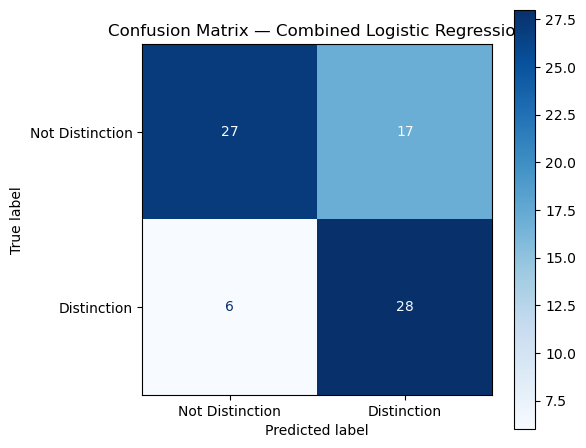

In [31]:
# Get predictions from best performing model — Combined Logistic Regression
best_model = combined_models['LogisticRegression']
y_pred_best = best_model.predict(X_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=['Not Distinction', 'Distinction'],
    cmap='Blues',
    ax=ax
)

ax.set_title('Confusion Matrix — Combined Logistic Regression')
plt.tight_layout()
plt.show()

## Confusion Matrix Observation

True Positive - 28 distinctions were accurately predicted
False Positive - 17 learners were predicted to achieve a Distinction but did not
True Negative - 27 Not distinctions were accurately predicted
False negative -  6 Not distinctions wre inaccurately predicted

The recall = 28/(28+6) = 82% which is good.
The precision = 28/(28+17) = 62% which is moderate. Here precision is slightly more important as we want to be able to intervene for learners who are predicted to not achieve a distinction. 
There are 17 distinctions that were predicted that turned out to be false which could prove challenging as these students may not get the required intervention they may need.
By using class_weight = 'balanced' we are instructing the model to penalise misclassifying the minority class so it will predict distinctions rather than 0 .
This intentionally favours recall over precision — however given our use case where false positives are more harmful, a future improvement would be to adjust the classification threshold to improve precision at the cost of some recall.

## Final

The notebook ingested the train_test split for both the stratified and combined datasets and proceeded to run a crossvalidated prediction model using 4 separate classification models. 
The best model identified was a logistic regression a the combined dataset producing an AUC of 0.71 compared to 0.5 for the stratified dataset.
There is a serious caveat with this modelling approach as the data is quite sparse and hard to train without causing serious overfitting due to data imbalances. Furthermore, as we are limited with features to produce a more robust prediction some data enrichment would be ideal with potential features such as learner scores, prior attainment, progress checks adding more context and prediction power.
The AUC uplift from 0.5 to 0.71 in the combined model is driven primarily by Apprenticeship Level — confirming that Level is the dominant predictor of distinction outcomes rather than EPAO or age bracket.
